Task 2: Feature Engineering, Model Optimization & Performance Comparison
California Housing Dataset | Maincrafts Technology AI/ML Internship

**Objective:** Prepare data correctly, apply feature scaling, train multiple regression models (Linear, Ridge, Decision Tree), compare results, and select the best model.

In [2]:
# Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
# Step 2: Load the California Housing Dataset
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

print("📦 Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print("\nColumn names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print()
df.head()

📦 Dataset loaded successfully!
Shape: (20640, 9)

Column names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'HousePrice']

Data types:
 MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
HousePrice    float64
dtype: object



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
# Dataset Overview - review column names, data types, target variable
print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"\nTotal samples : {df.shape[0]:,}")
print(f"Total features: {df.shape[1] - 1}")
print(f"Target column : HousePrice (Median House Value in $100,000s)")

print("\n--- Basic Statistics ---")
display(df.describe().round(3))

print("\n--- Missing Values ---")
print(df.isnull().sum())
print("\n✅ No missing values!" if df.isnull().sum().sum() == 0 else "⚠️ Missing values found!")

DATASET OVERVIEW

Total samples : 20,640
Total features: 8
Target column : HousePrice (Median House Value in $100,000s)

--- Basic Statistics ---


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
count,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000
mean,3.871,28.639,5.429,1.097,1425.477,3.071,35.632,-119.570,2.069
std,1.900,12.586,2.474,0.474,1132.462,10.386,2.136,2.004,1.154
min,0.500,1.000,0.846,0.333,3.000,0.692,32.540,-124.350,0.150
25%,2.563,18.000,4.441,1.006,787.000,2.430,33.930,-121.800,1.196
50%,3.535,29.000,5.229,1.049,1166.000,2.818,34.260,-118.490,1.797
75%,4.743,37.000,6.052,1.100,1725.000,3.282,37.710,-118.010,2.647
max,15.000,52.000,141.909,34.067,35682.000,1243.333,41.950,-114.310,5.000



--- Missing Values ---
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64

✅ No missing values!


In [5]:
# Step 3: Separate Features and Target Variable
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

print("✅ Features and target separated!")
print(f"\nX (features) shape : {X.shape}")
print(f"y (target)   shape : {y.shape}")
print(f"\nFeatures used: {X.columns.tolist()}")
print(f"\nTarget - HousePrice:")
print(f"  Min  : {y.min():.3f}  (${y.min()*100000:,.0f})")
print(f"  Max  : {y.max():.3f}  (${y.max()*100000:,.0f})")
print(f"  Mean : {y.mean():.3f}  (${y.mean()*100000:,.0f})")

✅ Features and target separated!

X (features) shape : (20640, 8)
y (target)   shape : (20640,)

Features used: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Target - HousePrice:
  Min  : 0.150  ($14,999)
  Max  : 5.000  ($500,001)
  Mean : 2.069  ($206,856)


In [6]:
# Step 4: Feature Scaling (Critical Step)
# Without scaling: some features dominate others → unstable performance
# StandardScaler transforms each feature to mean=0, std=1

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for readability
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("✅ Feature scaling applied using StandardScaler!")
print("\n--- Before Scaling (sample means & stds) ---")
print(X.describe().loc[['mean', 'std']].round(3))

print("\n--- After Scaling (should be ~0 mean, ~1 std) ---")
print(X_scaled_df.describe().loc[['mean', 'std']].round(3))

✅ Feature scaling applied using StandardScaler!

--- Before Scaling (sample means & stds) ---
      MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
mean   3.871    28.639     5.429      1.097    1425.477     3.071    35.632   
std    1.900    12.586     2.474      0.474    1132.462    10.386     2.136   

      Longitude  
mean   -119.570  
std       2.004  

--- After Scaling (should be ~0 mean, ~1 std) ---
      MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
mean     0.0       0.0       0.0       -0.0        -0.0       0.0      -0.0   
std      1.0       1.0       1.0        1.0         1.0       1.0       1.0   

      Longitude  
mean       -0.0  
std         1.0  


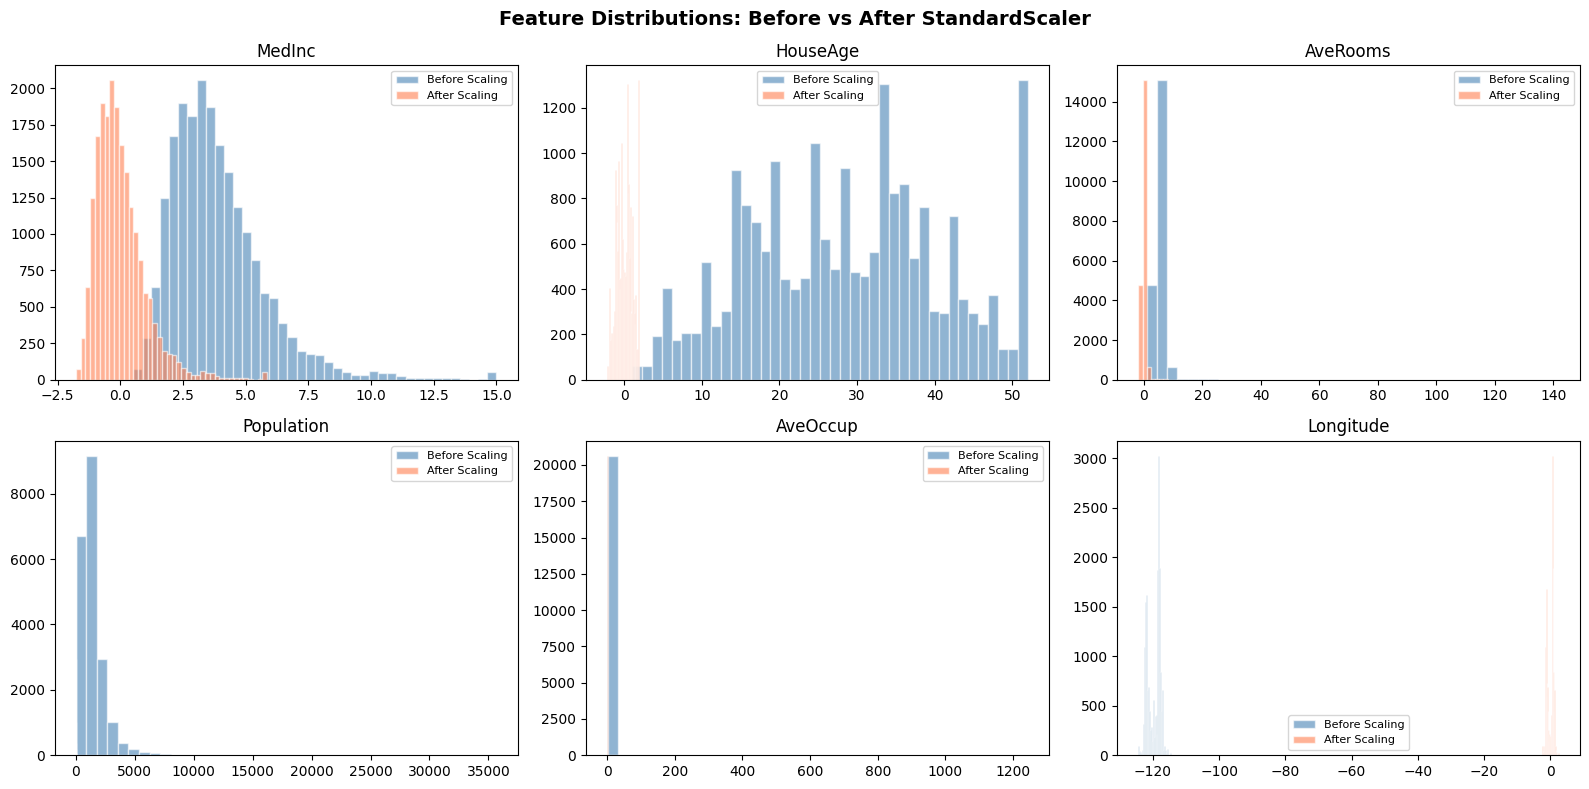

📊 Scaling comparison plot saved!


In [7]:
# Visualize the effect of scaling on a few features
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
features_to_show = ['MedInc', 'HouseAge', 'AveRooms', 'Population', 'AveOccup', 'Longitude']

for i, feat in enumerate(features_to_show):
    ax = axes[i // 3][i % 3]
    ax.hist(X[feat], bins=40, alpha=0.6, color='steelblue', label='Before Scaling', edgecolor='white')
    ax.hist(X_scaled_df[feat], bins=40, alpha=0.6, color='coral', label='After Scaling', edgecolor='white')
    ax.set_title(feat, fontsize=12)
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions: Before vs After StandardScaler', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('scaling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Scaling comparison plot saved!")

In [8]:
# Step 5: Train-Test Split
# Split AFTER scaling to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("✅ Data split into training and test sets!")
print(f"\n  Training samples : {X_train.shape[0]:,}  (80%)")
print(f"  Test samples     : {X_test.shape[0]:,}  (20%)")
print(f"  Features         : {X_train.shape[1]}")
print("\n  This ensures the model is evaluated on UNSEEN data only.")

✅ Data split into training and test sets!

  Training samples : 16,512  (80%)
  Test samples     : 4,128  (20%)
  Features         : 8

  This ensures the model is evaluated on UNSEEN data only.


In [9]:
# Step 6: Train Multiple Models
# Linear Regression  → baseline
# Ridge Regression   → reduces overfitting via L2 regularization
# Decision Tree      → captures non-linear relationships

models = {
    "Linear Regression"  : LinearRegression(),
    "Ridge Regression"   : Ridge(alpha=1.0),
    "Decision Tree"      : DecisionTreeRegressor(max_depth=5)
}

print("📋 Models defined:")
for name, model in models.items():
    print(f"  ✔ {name}")

print("\n🚀 Training all models...")
trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"  ✅ {name} trained!")

📋 Models defined:
  ✔ Linear Regression
  ✔ Ridge Regression
  ✔ Decision Tree

🚀 Training all models...
  ✅ Linear Regression trained!
  ✅ Ridge Regression trained!
  ✅ Decision Tree trained!


In [11]:
# Step 7: Model Evaluation and Comparison
results = {}

for name, model in trained_models.items():
    predictions = model.predict(X_test)

    # Calculate MSE first, then take square root for RMSE
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, predictions)
    r2   = r2_score(y_test, predictions)

    results[name] = {
        "RMSE"    : round(rmse, 4),
        "MAE"     : round(mae, 4),
        "R2 Score": round(r2, 4)
    }

# Create comparison table
results_df = pd.DataFrame(results).T
results_df["RMSE ($)"]     = (results_df["RMSE"] * 100000).astype(int)
results_df["MAE ($)"]      = (results_df["MAE"]  * 100000).astype(int)
results_df["R2 Score (%)"] = (results_df["R2 Score"] * 100).round(1)

print("=" * 65)
print("         📊 MODEL PERFORMANCE COMPARISON TABLE")
print("=" * 65)
display(results_df[["RMSE", "MAE", "R2 Score", "RMSE ($)", "MAE ($)", "R2 Score (%)"]])

print("\n📌 Interpretation:")
print("  • Lower RMSE → better prediction accuracy")
print("  • Lower MAE  → smaller average error")
print("  • Higher R²  → more variance explained by the model")

         📊 MODEL PERFORMANCE COMPARISON TABLE


,RMSE,MAE,R2 Score,RMSE ($),MAE ($),R2 Score (%)
Linear Regression,0.7456,0.5332,0.5758,74560,53320,57.6
Ridge Regression,0.7456,0.5332,0.5758,74560,53320,57.6
Decision Tree,0.7242,0.5223,0.5997,72420,52230,60.0



📌 Interpretation:
  • Lower RMSE → better prediction accuracy
  • Lower MAE  → smaller average error
  • Higher R²  → more variance explained by the model


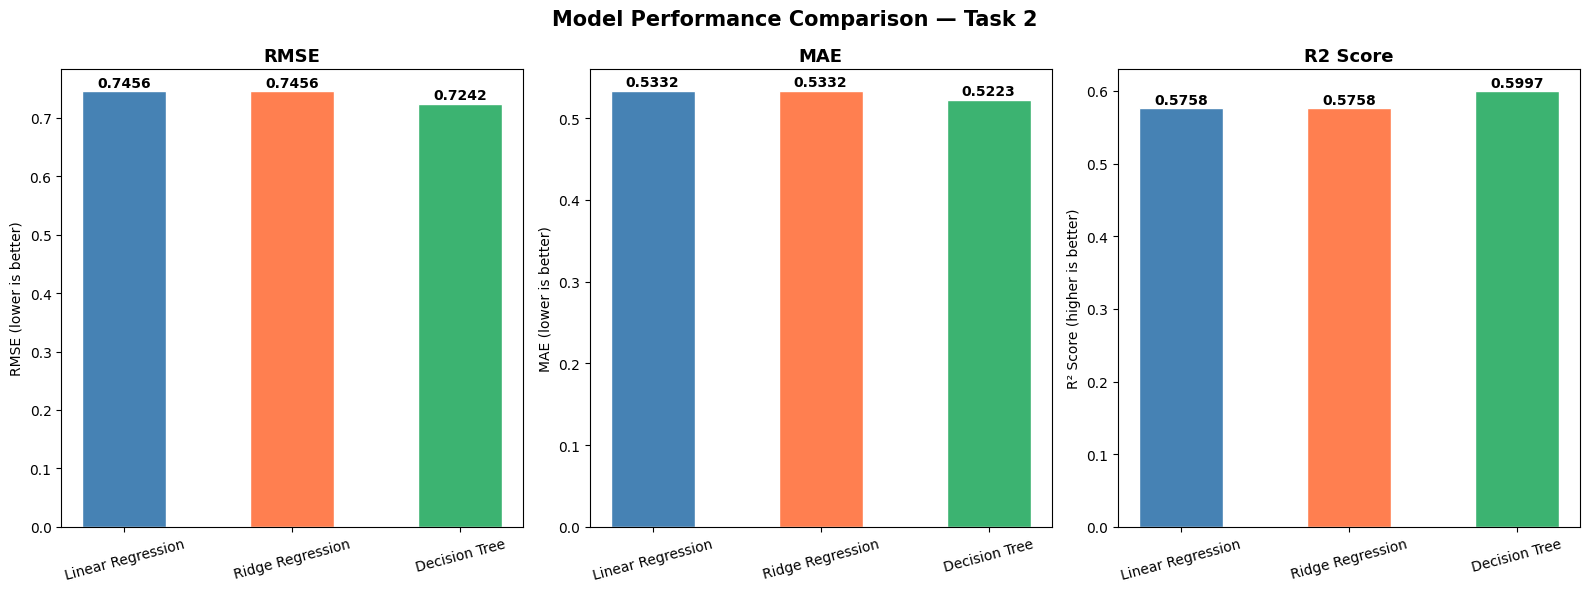

📊 Model comparison chart saved!


In [12]:
# Visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
model_names = list(results.keys())
colors = ['steelblue', 'coral', 'mediumseagreen']

metrics = ['RMSE', 'MAE', 'R2 Score']
ylabels = ['RMSE (lower is better)', 'MAE (lower is better)', 'R² Score (higher is better)']

for i, (metric, ylabel) in enumerate(zip(metrics, ylabels)):
    values = [results[m][metric] for m in model_names]
    bars = axes[i].bar(model_names, values, color=colors, edgecolor='white', width=0.5)
    axes[i].set_title(metric, fontsize=13, fontweight='bold')
    axes[i].set_ylabel(ylabel, fontsize=10)
    axes[i].tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.002,
                     f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Model Performance Comparison — Task 2', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Model comparison chart saved!")

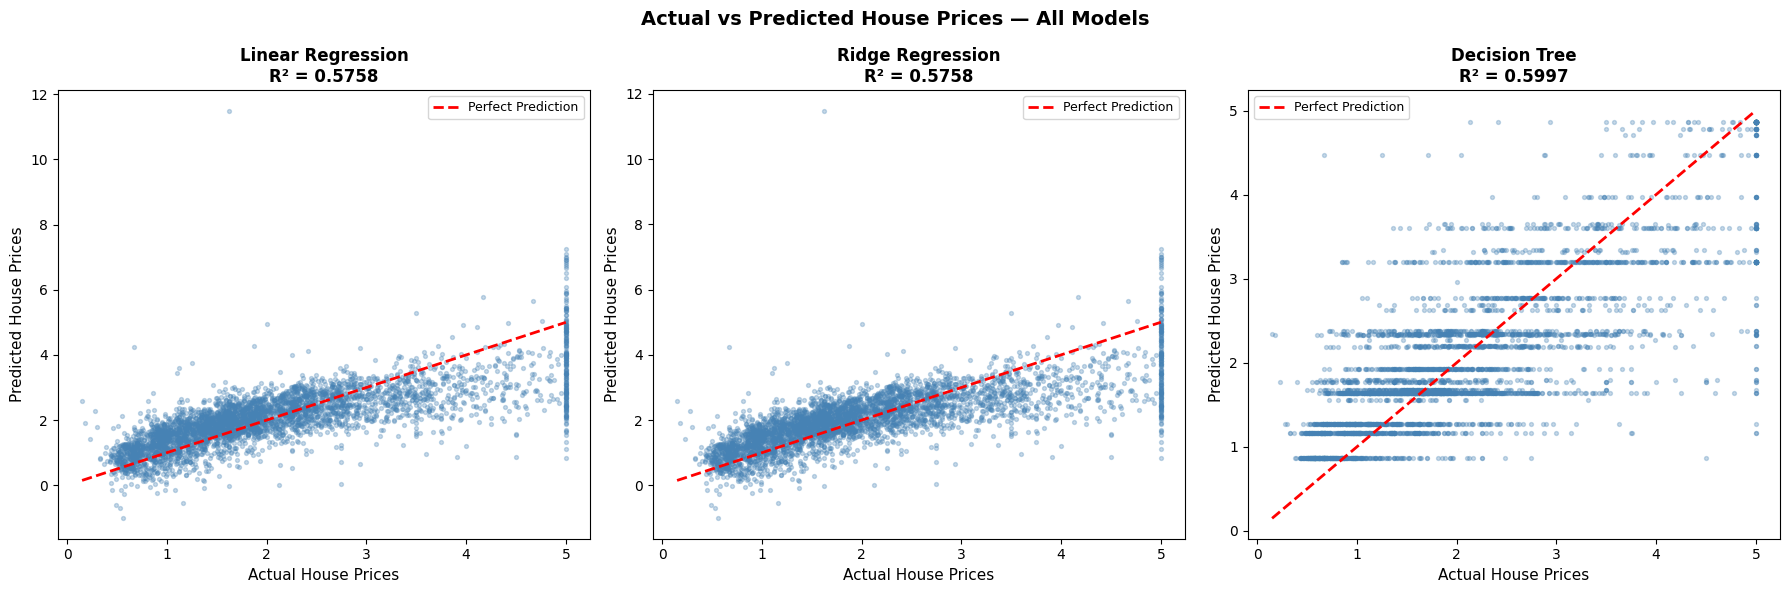

📌 A closer alignment of points to the red line = better model!


In [13]:
# Step 8: Visual Performance Validation
# Plot Actual vs Predicted for all 3 models

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, model) in zip(axes, trained_models.items()):
    predictions = model.predict(X_test)
    r2 = r2_score(y_test, predictions)

    ax.scatter(y_test, predictions, alpha=0.3, color='steelblue', s=8)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            color='red', linewidth=2, linestyle='--', label='Perfect Prediction')
    ax.set_xlabel('Actual House Prices', fontsize=11)
    ax.set_ylabel('Predicted House Prices', fontsize=11)
    ax.set_title(f'{name}\nR² = {r2:.4f}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Actual vs Predicted House Prices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('actual_vs_predicted_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("📌 A closer alignment of points to the red line = better model!")

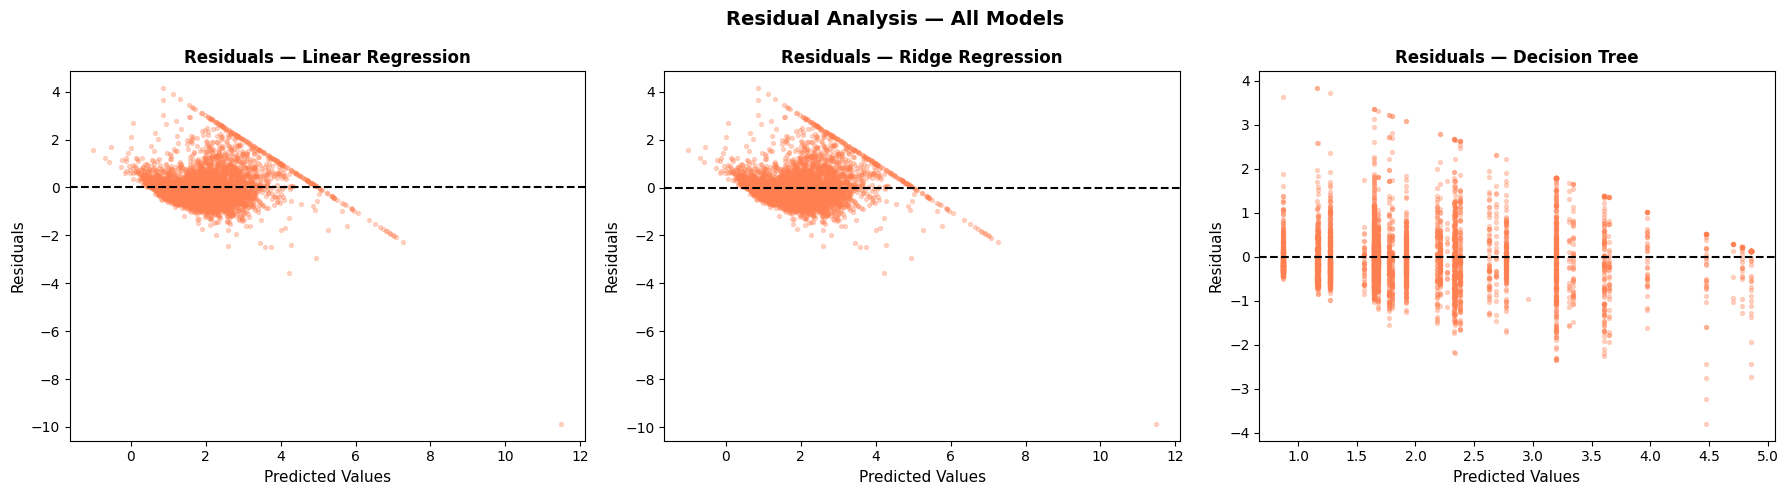

📌 Residuals should be randomly scattered around 0 for a good model.


In [14]:
# Residual plots for all 3 models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, trained_models.items()):
    predictions = model.predict(X_test)
    residuals   = y_test.values - predictions

    ax.scatter(predictions, residuals, alpha=0.3, color='coral', s=8)
    ax.axhline(y=0, color='black', linewidth=1.5, linestyle='--')
    ax.set_xlabel('Predicted Values', fontsize=11)
    ax.set_ylabel('Residuals', fontsize=11)
    ax.set_title(f'Residuals — {name}', fontsize=12, fontweight='bold')

plt.suptitle('Residual Analysis — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('residuals_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print("📌 Residuals should be randomly scattered around 0 for a good model.")

In [15]:
# Select the best model based on R² Score
best_name = max(results, key=lambda x: results[x]['R2 Score'])
best_model = trained_models[best_name]
best_r2    = results[best_name]['R2 Score']
best_rmse  = results[best_name]['RMSE']
best_mae   = results[best_name]['MAE']

print("=" * 55)
print("         🏆 BEST MODEL SELECTION")
print("=" * 55)
print(f"\n  Selected Model : {best_name}")
print(f"  R² Score       : {best_r2:.4f}  ({best_r2*100:.1f}% variance explained)")
print(f"  RMSE           : {best_rmse:.4f}  (${best_rmse*100000:,.0f})")
print(f"  MAE            : {best_mae:.4f}  (${best_mae*100000:,.0f})")
print(f"\n  Justification:")
print(f"  → Highest R² score means this model best explains")
print(f"    the variance in house prices.")
print(f"  → Lowest RMSE means predictions are closest to real values.")
print("=" * 55)

         🏆 BEST MODEL SELECTION

  Selected Model : Decision Tree
  R² Score       : 0.5997  (60.0% variance explained)
  RMSE           : 0.7242  ($72,420)
  MAE            : 0.5223  ($52,230)

  Justification:
  → Highest R² score means this model best explains
    the variance in house prices.
  → Lowest RMSE means predictions are closest to real values.


In [16]:
# Optional: Save the best-performing model using joblib
joblib.dump(best_model, 'best_model_task2.pkl')
joblib.dump(scaler,     'scaler_task2.pkl')

print(f"💾 Best model ({best_name}) saved as: best_model_task2.pkl")
print(f"💾 Scaler saved as: scaler_task2.pkl")

# Download in Colab
from google.colab import files
files.download('best_model_task2.pkl')
files.download('scaler_task2.pkl')

💾 Best model (Decision Tree) saved as: best_model_task2.pkl
💾 Scaler saved as: scaler_task2.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
# Final Summary Report
print("""
╔═══════════════════════════════════════════════════════════╗
║       TASK 2 — MODEL COMPARISON SUMMARY REPORT           ║
╠═══════════════════════════════════════════════════════════╣
║  Dataset    : California Housing (sklearn built-in)       ║
║  Samples    : 20,640  |  Features: 8                      ║
║  Scaling    : StandardScaler (mean=0, std=1)              ║
║  Split      : 80% train / 20% test  (random_state=42)    ║
╠═══════════════════════════════════════════════════════════╣
║  MODELS TRAINED                                           ║
║    1. Linear Regression   → Baseline model                ║
║    2. Ridge Regression    → Reduces overfitting (L2)      ║
║    3. Decision Tree       → Captures non-linearity        ║
╠═══════════════════════════════════════════════════════════╣""")

for name in results:
    r = results[name]
    marker = " 🏆" if name == best_name else "   "
    print(f"║{marker} {name:<22} R²={r['R2 Score']:.4f}  RMSE={r['RMSE']:.4f}  ║")

print(f"""╠═══════════════════════════════════════════════════════════╣
║  BEST MODEL : {best_name:<44}║
╠═══════════════════════════════════════════════════════════╣
║  KEY LEARNINGS                                            ║
║  • Feature scaling is critical — improves all models      ║
║  • Ridge handles multicollinearity better than Linear     ║
║  • Decision Tree captures non-linear patterns             ║
║  • Always compare multiple models before selecting one    ║
╚═══════════════════════════════════════════════════════════╝
""")


╔═══════════════════════════════════════════════════════════╗
║       TASK 2 — MODEL COMPARISON SUMMARY REPORT           ║
╠═══════════════════════════════════════════════════════════╣
║  Dataset    : California Housing (sklearn built-in)       ║
║  Samples    : 20,640  |  Features: 8                      ║
║  Scaling    : StandardScaler (mean=0, std=1)              ║
║  Split      : 80% train / 20% test  (random_state=42)    ║
╠═══════════════════════════════════════════════════════════╣
║  MODELS TRAINED                                           ║
║    1. Linear Regression   → Baseline model                ║
║    2. Ridge Regression    → Reduces overfitting (L2)      ║
║    3. Decision Tree       → Captures non-linearity        ║
╠═══════════════════════════════════════════════════════════╣
║    Linear Regression      R²=0.5758  RMSE=0.7456  ║
║    Ridge Regression       R²=0.5758  RMSE=0.7456  ║
║ 🏆 Decision Tree          R²=0.5997  RMSE=0.7242  ║
╠═════════════════════════════════